# Case Study III: 1977 Tenerife Runway Collision

The Tenerife airport disaster[c] occurred on 27 March 1977, when two Boeing 747 passenger jets collided on the runway at Los Rodeos Airport[1] (now Tenerife North–Ciudad de La Laguna Airport) on the Spanish island of Tenerife.
 - https://en.wikipedia.org/wiki/Tenerife_airport_disaster

In [43]:
import re
import glob
import pandas as pd
import spacy
import torch
import numpy as np
from sentence_transformers import SentenceTransformer, util

###############################################################################
# 1. Runway Pattern Functions (Updated)
###############################################################################

# Updated runway regex to handle runways without side designations
RUNWAY_REGEX = re.compile(
    r'(?i)(?:runway\s+)(?P<number>\d{1,2})\s*(?:(?P<side>[LR])|(?P<sideWord>right|left))?(?=\s|$|[.,;:!])'
)

def extract_all_runway_designators(text: str) -> list:
    """
    Return all runway designators found in the text as a list.
    This version recognizes designators written either as "34R" or as "8 right" (which is normalized to "08R").
    Also handles runways without side designations like "runway 12" or "runway 30".
    """
    designators = []
    for match in RUNWAY_REGEX.finditer(text):
        number = match.group("number")
        side = match.group("side")
        side_word = match.group("sideWord")
        # Format the number to always be two digits (e.g., "8" -> "08")
        number = number.zfill(2)
        if side_word:
            side = side_word[0].upper()  # Convert "right" or "left" to "R" or "L"
        if side:
            designators.append(f"{number}{side}")
        else:
            designators.append(number)
    return designators

def is_runway_pattern(text: str) -> bool:
    """Return True if at least one runway designator is found in the text."""
    return len(extract_all_runway_designators(text)) > 0

def format_runway_code(designator: str) -> str:
    """
    Format the runway designator by prepending 'RW'.
    For example, "8R" becomes "RW8R".
    """
    return f"RW{designator}"

def find_runway_entry_node(df: pd.DataFrame, runway_designator: str) -> str | None:
    """
    Given a runway designator (e.g. "8R"), look up the CSV row where that runway
    appears as an entry. In the CSV we assume that the runway entry is indicated by:
      - Either: refName1 equals the formatted runway code and type1 equals "Entry"
      - Or: refName2 equals the formatted runway code and type2 equals "Entry"
    Returns the node 'id' of the first matching row, or None if not found.
    """
    runway_code = format_runway_code(runway_designator)  # e.g. "RW8R"
    mask_ref1 = (df['refName1'] == runway_code) & (df['type1'].str.lower() == 'entry')
    mask_ref2 = (df['refName2'] == runway_code) & (df['type2'].str.lower() == 'entry')
    match_mask = mask_ref1 | mask_ref2
    matched_rows = df[match_mask]
    if not matched_rows.empty:
        return matched_rows.iloc[0]['id']
    return None

###############################################################################
# 2. Taxiway Pattern Functions (New)
###############################################################################

# Taxiway regex to capture taxiway designations like "Charlie 1", "taxiway Charlie 2"
TAXIWAY_REGEX = re.compile(
    r'(?i)(?:taxiway\s+)?(?P<name>[A-Z][a-z]{2,})\s+(?P<number>\d+)(?=\s|$|[.,;:!])'
)

def extract_all_taxiway_designators(text: str) -> list:
    """
    Return all taxiway designators found in the text as a list.
    This recognizes patterns like "Charlie 1", "taxiway Charlie 2", etc.
    Only matches names with at least 3 characters to avoid false matches.
    Excludes runway designations and common callsigns by filtering known patterns.
    """
    designators = []
    for match in TAXIWAY_REGEX.finditer(text):
        name = match.group("name")
        number = match.group("number")
        
        # Filter out known non-taxiway patterns
        if name.lower() in ["runway", "klm", "pa", "app", "rt", "make", "end", "the"]:
            continue
            
        designators.append(f"{name} {number}")
    return designators

def is_taxiway_pattern(text: str) -> bool:
    """Return True if at least one taxiway designator is found in the text."""
    return len(extract_all_taxiway_designators(text)) > 0

###############################################################################
# 3. Node Similarity Functions for Non-Runway Destinations
###############################################################################
def build_id_embeddings(df: pd.DataFrame, model_name='sentence-transformers/all-MiniLM-L6-v2'):
    """
    Build embeddings for the 'id' column of the CSV.
    Returns a tuple (model, embeddings).
    """
    model = SentenceTransformer(model_name)
    texts = df['id'].astype(str).tolist()
    embeddings = model.encode(texts, convert_to_tensor=True)
    return model, embeddings

def find_topk_similar_nodes(query: str, df: pd.DataFrame, model, embeddings, top_k=5):
    """
    Compute top-k similarity between the query and the embedded node IDs.
    Returns a list of dictionaries with the node id and similarity score.
    """
    query_emb = model.encode(query, convert_to_tensor=True)
    cos_scores = util.cos_sim(query_emb, embeddings)[0]
    top_results = torch.topk(cos_scores, k=top_k)
    results = []
    all_ids = df['id'].tolist()
    for i, idx_tensor in enumerate(top_results.indices):
        idx = idx_tensor.item()
        score = top_results.values[i].item()
        results.append({
            "id": all_ids[idx],
            "similarity_score": float(score)
        })
    return results

###############################################################################
# 4. Main Function: Build the Meta Table from the Transcript (Updated)
###############################################################################
if __name__ == "__main__":
    # --- Load your pretrained spaCy model and add your entity ruler ---
    nlp_ner = spacy.load("./transformer/model-best")
    # Add the entity ruler (adjust the pipe position as needed)
    ruler = nlp_ner.add_pipe("entity_ruler", after="ner", config={"overwrite_ents": True})
    ruler.from_disk("entity_rulers.jsonl")
    
    # --- Load the CSV with airport nodes ---
    ICAO = 'GCXO'
    airport_nodes = f'./Airport Layouts/{ICAO}_Nodes_Def.csv'
    df = pd.read_csv(airport_nodes)
    
    # Build embeddings for non-runway similarity search on the node "id" column.
    model_id, id_embeddings = build_id_embeddings(df)
    
    # List to collect meta table rows.
    meta_rows = []
    
    # --- Process transcript files ---
    # https://www.pbs.org/wgbh/nova/planecrash/minutes.html
    test_file_paths = glob.glob('/home/yp6443/research/nlp/voice_data/test_file/*.txt')
    file_idx = 1  # adjust as needed

    with open(test_file_paths[file_idx], 'r') as file:
        for line in file:
            line_text = line.strip()
            if not line_text:
                continue
            
            # Extract the time as the first token in the line.
            time_val = line_text.split()[0]
            
            # Run your spaCy NER on the line.
            doc = nlp_ner(line_text)
            print(f"\nLine: \"{line_text}\"")
            print("Entities found:")
            for ent in doc.ents:
                print(f"  - {ent.text} : {ent.label_}")
            
            # Initialize fields (if an entity is missing, the field remains empty).
            callsign = ""
            destination_text = ""
            ac_state_list = []
            
            # Extract entity values (adjust label names as used by your model).
            for ent in doc.ents:
                if ent.label_ == "CALLSIGN":
                    callsign = ent.text
                elif ent.label_ == "DESTINATION":
                    destination_text = ent.text
                elif ent.label_ == "ACSTATE":  # or "AC_STATE" if that is your model's label
                    ac_state_list.append(ent.text)
            ac_state = ",".join(ac_state_list)
            
            # --- Determine the destination runway and final destination ---
            # First, try applying the regex to the entire line.
            designators_line = extract_all_runway_designators(line_text)
            taxiways_line = extract_all_taxiway_designators(line_text)
            
            if designators_line:
                # If found in the entire line, choose the last designator.
                chosen = designators_line[-1]
                dest_runway = chosen
                entry_node = find_runway_entry_node(df, chosen)
                if entry_node:
                    final_destination = entry_node
                else:
                    final_destination = f"No entry found for runway {chosen}"
            elif taxiways_line:
                # If taxiways are found, use the last one as destination
                chosen_taxiway = taxiways_line[-1]
                dest_runway = ""
                final_destination = chosen_taxiway
            else:
                # Otherwise, fall back to checking the DESTINATION entity.
                if destination_text and is_runway_pattern(destination_text):
                    designators = extract_all_runway_designators(destination_text)
                    chosen = designators[-1] if designators else None
                    if chosen:
                        dest_runway = chosen
                        entry_node = find_runway_entry_node(df, chosen)
                        if entry_node:
                            final_destination = entry_node
                        else:
                            final_destination = f"No entry found for runway {chosen}"
                    else:
                        final_destination = destination_text
                        dest_runway = ""
                elif destination_text and is_taxiway_pattern(destination_text):
                    taxiways = extract_all_taxiway_designators(destination_text)
                    chosen_taxiway = taxiways[-1] if taxiways else None
                    if chosen_taxiway:
                        dest_runway = ""
                        final_destination = chosen_taxiway
                    else:
                        final_destination = destination_text
                        dest_runway = ""
                else:
                    dest_runway = ""
                    # For non-runway orders, use the destination_text.
                    final_destination = destination_text
            
            # Build a meta table row.
            meta_row = {
                "callsign": callsign,
                "time": time_val,
                "ac_state": ac_state,
                "dest_runway": dest_runway,
                "destination": final_destination
            }
            meta_rows.append(meta_row)
    
    # Create and print the meta table.
    meta_df = pd.DataFrame(meta_rows, columns=["callsign", "time", "ac_state", "dest_runway", "destination"])
    
    # -----------------------
    # Post-Processing Step:
    # For each callsign, if a dest_runway is provided on any row, propagate it to all rows of that callsign.
    # Replace empty strings with NaN for proper filling.
    meta_df['dest_runway'] = meta_df['dest_runway'].replace('', np.nan)
    # For each callsign, forward-fill then backward-fill the dest_runway.
    meta_df['dest_runway'] = meta_df.groupby('callsign')['dest_runway'].transform(lambda x: x.ffill().bfill())
    # Replace NaN back with an empty string if desired.
    meta_df['dest_runway'] = meta_df['dest_runway'].fillna('')
    # -----------------------
    meta_df = meta_df[~meta_df['time'].isin(['N/A'])]
    
    print("\nFinal Meta Table:")
    print(meta_df.reset_index(drop=True))

/home/yp6443/anaconda3/envs/nlp/lib/python3.10/site-packages/spacy_transformers/layers/hf_shim.py:124: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self._model.load_state_d


Line: "1658:14.8   KLM RT    Approach KLM 4805 on the ground in Tenerife."
Entities found:
  - Approach : ACSTATE
  - KLM 4805 : CALLSIGN
  - Tenerife : DESTINATION

Line: "1658:21.5   APP       KLM 4805, roger."
Entities found:
  - KLM 4805 : CALLSIGN

Line: "1658:25.7   KLM RT    We require backtrack on runway 12 for takeoff Runway 30."
Entities found:
  - backtrack : ACSTATE
  - runway 12 : DESTINATION
  - takeoff : ACSTATE
  - Runway 30 : DESTINATION

Line: "1658:30.4   APP       Okay, KLM 4805 taxi to the holding position Runway 30. Taxi into the runway and—ah—leave runway (third) to your left."
Entities found:
  - KLM 4805 : CALLSIGN
  - taxi : ACSTATE
  - holding : ACSTATE
  - Runway 30 : DESTINATION
  - Taxi : ACSTATE
  - runway : DESTINATION
  - runway : DESTINATION

Line: "1658:47.4   KLM RT    Roger, sir, (entering) the runway at this time and the first (taxiway) we, we go off the runway again for the beginning of Runway 30."
Entities found:
  - entering : ACSTATE
  - runwa

/tmp/ipykernel_2212289/3632438295.py:255: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  meta_df['dest_runway'] = meta_df.groupby('callsign')['dest_runway'].transform(lambda x: x.ffill().bfill())


In [44]:
print("Meta Table:")
pd.set_option('display.max_rows', None)
meta_df

Meta Table:


,callsign,time,ac_state,dest_runway,destination
0,KLM 4805,1658:14.8,Approach,30,Tenerife
1,KLM 4805,1658:21.5,,30,
2,,1658:25.7,"backtrack,takeoff",30,Rwy_12_006
3,KLM 4805,1658:30.4,"taxi,holding,Taxi",30,Rwy_12_006
4,,1658:47.4,"entering,go",30,Rwy_12_006
5,,1658:55.3,taxi,30,runway
6,,1659:04.5,,30,
7,KLM 4805,1659:10.0,,30,runway
8,KLM 4805,1659:15.9,,30,
9,,1659:28.4,"Approach,turn left",30,Charlie 1


In [45]:
meta_df = meta_df[meta_df['ac_state'].str.strip() != '']

accident_time = "1706:50.00"
accident_callsign = "KLM 4805"
new_row_1 = {
        "callsign": accident_callsign,
        "time": accident_time,
        "ac_state": "collision",
        "dest_runway": "",      # Could be left empty if not available.
        "destination": ""
        }

meta_df = pd.concat([meta_df, pd.DataFrame([new_row_1])], ignore_index=True)
    
accident_callsign = "Clipper 1736"
new_row_2 = {
        "callsign": accident_callsign,
        "time": accident_time,
        "ac_state": "collision",
        "dest_runway": "",      # Could be left empty if not available.
        "destination": ""
        }
meta_df = pd.concat([meta_df, pd.DataFrame([new_row_2])], ignore_index=True)

meta_df

,callsign,time,ac_state,dest_runway,destination
0,KLM 4805,1658:14.8,Approach,30,Tenerife
1,,1658:25.7,"backtrack,takeoff",30,Rwy_12_006
2,KLM 4805,1658:30.4,"taxi,holding,Taxi",30,Rwy_12_006
3,,1658:47.4,"entering,go",30,Rwy_12_006
4,,1658:55.3,taxi,30,runway
5,,1659:28.4,"Approach,turn left",30,Charlie 1
6,,1659:32.2,taxi,30,end of the runway
7,,1702:03.6,taxi,30,runway
8,,1702:08.4,"taxi,leave",30,runway
9,,1702:49.8,pass,30,


In [46]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# === Load the airport nodes CSV ===
ICAO = 'GCXO'
airport_nodes_path = f'./Airport Layouts/{ICAO}_Nodes_Def.csv'
df_nodes = pd.read_csv(airport_nodes_path)
# (Assume df_nodes has a column called "id" that contains node names.)

# === Build embeddings for the airport nodes based on the "id" column ===
# (Assuming your build_id_embeddings function returns a model with an .encode() method and the list/array of embeddings.)
model_id, id_embeddings = build_id_embeddings(df_nodes)
# For example, id_embeddings might be a NumPy array of shape (num_nodes, embedding_dim).

# === Define a function to return the top k most similar node ids given a query string ===
def get_top_k_similar(query, model, embeddings, node_ids, k=3):
    """
    Given a query string, a model, and precomputed embeddings for node_ids,
    returns the top k most similar node ids along with their similarity scores.
    """
    # Compute embedding for the query string:
    query_embedding = model.encode(query)
    
    # Compute cosine similarity between the query and all node embeddings:
    sims = cosine_similarity([query_embedding], embeddings)[0]
    
    # Get indices for the top k similar nodes (sorted by descending similarity):
    top_indices = np.argsort(sims)[::-1][:k]
    
    # Return a list of tuples: (node_id, similarity score)
    return [(node_ids[i], sims[i]) for i in top_indices]

# === Filter the flight log for rows where the destination matches any of the target keywords ===
# Define your target keywords
keywords = ['Charlie 1', 'end of the runway']

# Create a regex pattern that matches any of these keywords.
# The pipe character '|' acts as a logical OR in regex.
pattern = '|'.join(keywords)

# Assuming your flight log DataFrame is called meta_df, create the mask:
mask = meta_df['destination'].str.contains(pattern, case=False, na=False)

# Filter the DataFrame and remove duplicate destination entries (if needed)
df_filtered = meta_df[mask].drop_duplicates(subset=['destination'])

# Get the list of node ids from the airport nodes DataFrame.
node_ids = df_nodes['id'].tolist()

# === For each filtered destination, find the top k similar node names ===
k = 5  # Adjust as needed
for idx, row in df_filtered.iterrows():
    destination_query = row['destination']
    similar_nodes = get_top_k_similar(destination_query, model_id, id_embeddings, node_ids, k=k)
    print(f"Destination '{destination_query}' top {k} similar nodes:")
    for node_name, score in similar_nodes:
        print(f"  {node_name}: {score:.4f}")
    print()

Destination 'Charlie 1' top 5 similar nodes:
  Rwy_12_001: 0.2609
  Rwy_12_006: 0.2587
  Rwy_12_005: 0.2571
  Rwy_12_002: 0.2553
  Rwy_12_003: 0.2532

Destination 'end of the runway' top 5 similar nodes:
  Rwy_12_002: 0.1695
  Rwy_12_004: 0.1671
  Rwy_12_001: 0.1577
  Rwy_12_003: 0.1560
  Rwy_12_006: 0.1553



In [47]:
from KShortestPaths_TaxiPlanGenerator import *

airports = [
    "AMS", "BOM", "CAI", "CDG", "DEL", "DME", "DXB", "FCO", "FRA", "HKG", "HND",
    "ICN", "IST", "JNB", "KABQ", "KATL", "KBDL", "KBHM", "KBNA", "KBOI", "KBOS",
    "KBTV", "KBUR", "KBWI", "KBZN", "KCHS", "KCLE", "KCLT", "KCRW", "KCVG", "KDAL",
    "KDCA", "KDEN", "KDFW", "KDSM", "KDTW", "KEWR", "KFAR", "KFLL", "KFSD", "KGYY",
    "KHPN", "KIAD", "KIAH", "KICT", "KILG", "KIND", "KISP", "KJAC", "KJAN", "KJAX",
    "KJFK", "KLAS", "KLAX", "KLEX", "KLGA", "KLGB", "KLIT", "KMCO", "KMDW", "KMEM",
    "KMHT", "KMIA", "KMKE", "KMSP", "KMSY", "KOAK", "KOKC", "KOMA", "KONT", "KORD",
    "KPBI", "KPDX", "KPHL", "KPHX", "KPIT", "KPVD", "KPWM", "KSAN", "KSAT", "KSDF",
    "KSEA", "KSFO", "KSJC", "KSLC", "KSNA", "KSTL", "KSWF", "KTEB", "KTPA", "KUL",
    "KVGT", "LHR", "MAD", "MEX", "PANC", "PEK", "PHNL", "PVG", "SIN", "SYD", "TLV",
    "TPE", "YYZ", "GCXO"
]
defFiles = [os.getcwd() + f"/Airport Layouts/{airport}_Nodes_Def.csv" for airport in airports]
linkFiles = [os.getcwd() + f"/Airport Layouts/{airport}_Nodes_Links.csv" for airport in airports]
graphs, nodePositions = loadData(defFiles, linkFiles)

graph = graphs.get(ICAO)
positions = nodePositions.get(ICAO)
NUM_PATHS = 1

# KLM 4805
start11 = 'Rwy_12_001'
end11 = 'Rwy_12_006'
start12 = 'Rwy_12_006'
end12 = 'Rwy_12_005'
# Clipper 1736
start21 = 'Txy_C0_001'
end21 = 'Rwy_12_001'
start22 = 'Rwy_12_001'
end22 = 'Rwy_12_005'
# Generate paths for KLM 4805 (two segments)
path11 = aStarMultiple(graph, start11, end11, positions, k=NUM_PATHS)
path12 = aStarMultiple(graph, start12, end12, positions, k=NUM_PATHS)

# Append node names for path 1 and calculate total distance
path1_nodes = []
path1_total_distance = 0.0

# Process path11 (first segment)
for path, distance in path11:
    path1_nodes.extend(path)
    path1_total_distance += distance

# Process path12 (second segment) - remove duplicate node if it exists
for path, distance in path12:
    # Remove the first node if it's the same as the last node of path11
    if path1_nodes and path and path[0] == path1_nodes[-1]:
        path1_nodes.extend(path[1:])  # Skip the first node to avoid duplication
    else:
        path1_nodes.extend(path)
    path1_total_distance += distance

# Create the combined path1 with total distance
path1 = [(path1_nodes, path1_total_distance)]

# Generate paths for Clipper 1736 (two segments)
path21 = aStarMultiple(graph, start21, end21, positions, k=NUM_PATHS)
path22 = aStarMultiple(graph, start22, end22, positions, k=NUM_PATHS)

# Append node names for path 2 and calculate total distance
path2_nodes = []
path2_total_distance = 0.0

# Process path21 (first segment)
for path, distance in path21:
    path2_nodes.extend(path)
    path2_total_distance += distance

# Process path22 (second segment) - remove duplicate node if it exists
for path, distance in path22:
    # Remove the first node if it's the same as the last node of path21
    if path2_nodes and path and path[0] == path2_nodes[-1]:
        path2_nodes.extend(path[1:])  # Skip the first node to avoid duplication
    else:
        path2_nodes.extend(path)
    path2_total_distance += distance

# Create the combined path2 with total distance
path2 = [(path2_nodes, path2_total_distance)]

print('KLM 4805 Possible Paths:')
for i, (path, distance) in enumerate(path1, start=1):
    print(f"Path {i}: {path}, Total Distance: {distance:.2f} mile")

print('Clipper 1736 Possible Paths:')
for i, (path, distance) in enumerate(path2, start=1):
    print(f"Path {i}: {path}, Total Distance: {distance:.2f} mile")


KLM 4805 Possible Paths:
Path 1: ['Rwy_12_001', 'Rwy_12_002', 'Rwy_12_003', 'Rwy_12_004', 'Rwy_12_005', 'Rwy_12_006', 'Rwy_12_005'], Total Distance: 2.88 mile
Clipper 1736 Possible Paths:
Path 1: ['Txy_C0_001', 'Txy_C0_002', 'Rwy_12_001', 'Rwy_12_002', 'Rwy_12_003', 'Rwy_12_004', 'Rwy_12_005'], Total Distance: 1.32 mile


In [48]:
# Precise timing animation functions
import math
import io
import os
import imageio
import matplotlib.pyplot as plt
import pandas as pd

def calculate_segment_distances(path, nodePositions):
    """Calculate distances for each segment in the path"""
    distances = []
    for i in range(len(path) - 1):
        pos1 = nodePositions[path[i]]
        pos2 = nodePositions[path[i+1]]
        # Calculate distance in miles (assuming lat/lon are in degrees)
        # Rough conversion: 1 degree ≈ 69 miles
        distance_miles = math.sqrt((pos2[0] - pos1[0])**2 + (pos2[1] - pos1[1])**2) * 69
        distances.append(distance_miles)
    return distances

def get_position_along_path_precise_timing(path, nodePositions, segment_times, t):
    """
    Given a list of node IDs in 'path', returns the interpolated position (lat, lon)
    at simulation time t (in seconds), based on precise timing for each segment.
    
    Args:
        path: List of node IDs
        nodePositions: Dictionary of node positions
        segment_times: List of time durations for each segment (seconds)
        t: Time in seconds
    """
    # Ensure we have the right number of segment times
    if len(segment_times) != len(path) - 1:
        raise ValueError(f"segment_times must have {len(path) - 1} elements, got {len(segment_times)}")

    # Compute cumulative times along the path segments
    cum_times = [0]
    for i in range(len(segment_times)):
        cum_times.append(cum_times[-1] + segment_times[i])
    
    total_time = cum_times[-1]

    # If we've passed the total time, return the final node position.
    if t >= total_time:
        return nodePositions[path[-1]], total_time

    # Find the segment where the current time lies.
    for i in range(1, len(cum_times)):
        if t < cum_times[i]:
            pos1 = nodePositions[path[i-1]]
            pos2 = nodePositions[path[i]]
            seg_progress = (t - cum_times[i-1]) / (cum_times[i] - cum_times[i-1])
            lat = pos1[0] + seg_progress * (pos2[0] - pos1[0])
            lon = pos1[1] + seg_progress * (pos2[1] - pos1[1])
            return (lat, lon), total_time

def animate_precise_timing(linksDf, nodePositions, path1, segment_times1, path2, segment_times2, airport_name, output_filename, collision_time, xlims=None, ylims=None, time_lag=0, save_frames_dir=None):
    """
    Animates two aircraft with precise timing control and optional time lag.
    """
    
    # Calculate total times
    total_time1 = sum(segment_times1)
    total_time2 = sum(segment_times2)
    overall_total_time = max(total_time1, total_time2 + time_lag)
    
    print(f"Aircraft 1 total time: {total_time1} seconds")
    print(f"Aircraft 2 total time: {total_time2} seconds")
    print(f"Aircraft 2 starts at: {time_lag} seconds")
    print(f"Collision time: {collision_time} seconds")

    frames = []
    for t in range(overall_total_time + 1):
        # Calculate positions for both aircraft
        pos1, _ = get_position_along_path_precise_timing(path1, nodePositions, segment_times1, t)
        
        # Aircraft 2 starts after time_lag
        if t >= time_lag:
            pos2, _ = get_position_along_path_precise_timing(path2, nodePositions, segment_times2, t - time_lag)
        else:
            # Aircraft 2 hasn't started yet, use starting position
            pos2 = nodePositions[path2[0]]
        
        # Create figure
        fig, ax = plt.subplots(figsize=(10, 10))
        
        # Set custom zoom (if provided)
        if xlims is not None:
            ax.set_xlim(xlims)
        if ylims is not None:
            ax.set_ylim(ylims)
            
        # Draw background
        for _, row in linksDf.iterrows():
            try:
                n1_lon = float(row['n1.lon'])
                n1_lat = float(row['n1.lat'])
                n2_lon = float(row['n2.lon'])
                n2_lat = float(row['n2.lat'])
                ax.plot([n1_lon, n2_lon], [n1_lat, n2_lat], color='gray', linestyle='-', linewidth=0.5)
            except:
                continue

        # Draw nodes
        for nodeId, (lat, lon) in nodePositions.items():
            ax.scatter(lon, lat, color='blue', s=20, zorder=2)
            ax.text(lon, lat, nodeId, fontsize=12, ha='right', va='bottom')
        
        # Plot the planned paths
        path1_lats = [nodePositions[node][0] for node in path1]
        path1_lons = [nodePositions[node][1] for node in path1]
        ax.plot(path1_lons, path1_lats, color='red', linestyle='--', linewidth=2, label='KLM 4805')
        
        # Only plot path2 if aircraft 2 has started
        if t >= time_lag:
            path2_lats = [nodePositions[node][0] for node in path2]
            path2_lons = [nodePositions[node][1] for node in path2]
            ax.plot(path2_lons, path2_lats, color='green', linestyle='--', linewidth=2, label='Clipper 1736')
        
        # Plot current positions
        ax.scatter(pos1[1], pos1[0], color='red', s=100, zorder=3, label='KLM 4805' if t==0 else "")
        
        # Only plot aircraft 2 if it has started
        if t >= time_lag:
            ax.scatter(pos2[1], pos2[0], color='green', s=100, zorder=3, label='Clipper 1736' if t==time_lag else "")
        else:
            # Show aircraft 2 at starting position but with different styling
            ax.scatter(pos2[1], pos2[0], color='lightgray', s=50, zorder=2, alpha=0.5, label='Clipper 1736 (waiting)' if t==0 else "")
        
        # Check for collision
        collision_detected = False
        if t == collision_time:
            # Show collision warning
            ax.scatter(pos1[1], pos1[0], color='yellow', s=200, marker='*', zorder=4, label='COLLISION!' if t==collision_time else "")
            collision_detected = True
        
        # Display simulation time and status
        status_text = f"t = {t} s"
        if t < time_lag:
            status_text += f"\\nAircraft 2 starts in {time_lag - t} s"
        elif t == time_lag:
            status_text += f"\\nAircraft 2 starts now!"
        elif collision_detected:
            status_text += f"\\nCOLLISION!"
        elif t > collision_time:
            status_text += f"\\nPost-collision"
        
        ax.text(0.05, 0.05, status_text, transform=ax.transAxes,
                fontsize=12, color='black', verticalalignment='bottom',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        
        # Add legend
        ax.legend(loc='upper right')
        
        if save_frames_dir:
            # Save each frame as a PNG file.
            frame_filename = os.path.join(save_frames_dir, f'{airport_name}_frame_{t:04d}.png')
            plt.savefig(frame_filename, format='png', dpi=300)
            # print(f"Saved frame: {frame_filename}")
        else:
            # Save the frame to an in-memory buffer.
            buf = io.BytesIO()
            plt.savefig(buf, format='png', dpi=300)
            buf.seek(0)
            image = imageio.imread(buf)
            frames.append(image)
        
        plt.close(fig)
    
    if not save_frames_dir:
        # Save all frames as an animated GIF if not saving individual images.
        imageio.mimsave(output_filename, frames, duration=0.1)
        print(f"Animation saved to {output_filename}")
    else:
        print(f"Individual frames saved to {save_frames_dir}")


In [49]:
# FINAL FIX: Use the correct coordinates and timing
print("=== FINAL FIX: CORRECT COORDINATES AND TIMING ===")

# Get the actual paths
path_klm = path1[0][0]  # KLM 4805 path
path_clipper = path2[0][0]  # Clipper 1736 path

print(f"KLM 4805 path: {path_klm}")
print(f"KLM segments: {len(path_klm) - 1}")
print(f"Clipper 1736 path: {path_clipper}")
print(f"Clipper segments: {len(path_clipper) - 1}")

# Use the corrected segment times we calculated
klm_segment_times = [76, 53, 49, 35, 190, 54]  # Total: 457 seconds
# First 3 segments: 76 + 53 + 49 = 178 seconds
# Segments 4,5: 35 + 190 = 225 seconds  
# Last segment: 54 seconds

clipper_segment_times = [121, 57, 96, 67, 62, 54]  # Total: 457 seconds
# First 2 segments: 121 + 57 = 178 seconds
# Segments 3,4,5: 96 + 67 + 62 = 225 seconds  
# Last segment: 54 seconds

print(f"\nKLM segment times: {klm_segment_times} (length: {len(klm_segment_times)})")
print(f"Clipper segment times: {clipper_segment_times} (length: {len(clipper_segment_times)})")

# Verify timing
klm_total_time = sum(klm_segment_times)
clipper_total_time = sum(clipper_segment_times)
clipper_start_time = 0  # Both aircraft start at the same time now

print(f"\nKLM total time: {klm_total_time} seconds")
print(f"Clipper total time: {clipper_total_time} seconds")
print(f"Both aircraft start at: t=0 seconds")

# Collision occurs when both aircraft reach the same point
collision_time = max(klm_total_time, clipper_total_time)

print(f"Collision time: {collision_time} seconds")

# Use the correct nodePositions from the path generation system
# This is the key fix - use 'positions' not 'nodePositions'
correct_nodePositions = positions  # This comes from the path generation code

print(f"\nUsing nodePositions with {len(correct_nodePositions)} nodes")
print("Sample nodes:")
for i, (node, pos) in enumerate(list(correct_nodePositions.items())[:5]):
    print(f"  {node}: {pos}")

# Load the links data for the animation
linksDf = pd.read_csv(f'./Airport Layouts/{ICAO}_Nodes_Links.csv')

# Create the animation with the correct timing and nodePositions
animate_precise_timing(
    linksDf=linksDf,
    nodePositions=correct_nodePositions,
    path1=path_klm,
    segment_times1=klm_segment_times,
    path2=path_clipper,
    segment_times2=clipper_segment_times,
    airport_name=ICAO,
    output_filename='case-study-3.gif',
    collision_time=collision_time,
    xlims=None,
    ylims=None,
    time_lag=clipper_start_time,
    save_frames_dir='frames'
)


=== FINAL FIX: CORRECT COORDINATES AND TIMING ===
KLM 4805 path: ['Rwy_12_001', 'Rwy_12_002', 'Rwy_12_003', 'Rwy_12_004', 'Rwy_12_005', 'Rwy_12_006', 'Rwy_12_005']
KLM segments: 6
Clipper 1736 path: ['Txy_C0_001', 'Txy_C0_002', 'Rwy_12_001', 'Rwy_12_002', 'Rwy_12_003', 'Rwy_12_004', 'Rwy_12_005']
Clipper segments: 6

KLM segment times: [76, 53, 49, 35, 190, 54] (length: 6)
Clipper segment times: [121, 57, 96, 67, 62, 54] (length: 6)

KLM total time: 457 seconds
Clipper total time: 457 seconds
Both aircraft start at: t=0 seconds
Collision time: 457 seconds

Using nodePositions with 19 nodes
Sample nodes:
  Rwy_12_001: (28.487889, -16.357273)
  Rwy_12_002: (28.485553, -16.350255)
  Rwy_12_003: (28.483932, -16.34536)
  Rwy_12_004: (28.482443, -16.340874)
  Rwy_12_005: (28.481667, -16.338548)
Aircraft 1 total time: 457 seconds
Aircraft 2 total time: 457 seconds
Aircraft 2 starts at: 0 seconds
Collision time: 457 seconds
Individual frames saved to frames


# Speed Parameter Estimation

In [50]:
# Simple speed calculation - just distance/time
import math

print("Simple speed calculation...")

# KLM 4805 speeds
print("KLM 4805:")
for i in range(len(path_klm) - 1):
    pos1 = correct_nodePositions[path_klm[i]]
    pos2 = correct_nodePositions[path_klm[i+1]]
    # Simple distance: 1 degree ≈ 111 km
    distance_km = math.sqrt((pos2[0] - pos1[0])**2 + (pos2[1] - pos1[1])**2) * 111
    # Speed = Distance / Time (convert to km/h)
    speed_kmh = (distance_km / klm_segment_times[i]) * 3600
    print(f"Segment {i+1}: {speed_kmh:.2f} km/h")

print("\nClipper 1736:")
for i in range(len(path_clipper) - 1):
    pos1 = correct_nodePositions[path_clipper[i]]
    pos2 = correct_nodePositions[path_clipper[i+1]]
    # Simple distance: 1 degree ≈ 111 km
    distance_km = math.sqrt((pos2[0] - pos1[0])**2 + (pos2[1] - pos1[1])**2) * 111
    # Speed = Distance / Time (convert to km/h)
    speed_kmh = (distance_km / clipper_segment_times[i]) * 3600
    print(f"Segment {i+1}: {speed_kmh:.2f} km/h")


Simple speed calculation...
KLM 4805:
Segment 1: 38.89 km/h
Segment 2: 38.88 km/h
Segment 3: 38.55 km/h
Segment 4: 28.00 km/h
Segment 5: 28.40 km/h
Segment 6: 99.91 km/h

Clipper 1736:
Segment 1: 3.64 km/h
Segment 2: 3.37 km/h
Segment 3: 30.79 km/h
Segment 4: 30.75 km/h
Segment 5: 30.46 km/h
Segment 6: 18.15 km/h


In [51]:
# Debug: Compare distance calculation methods
import math

print("=== DISTANCE CALCULATION COMPARISON ===")

# Method 1: Simple lat/lon distance (used in speed calculation)
print("Method 1: Simple lat/lon distance (1 degree ≈ 111 km)")
print("KLM 4805 segments:")
for i in range(len(path_klm) - 1):
    pos1 = correct_nodePositions[path_klm[i]]
    pos2 = correct_nodePositions[path_klm[i+1]]
    distance_km_simple = math.sqrt((pos2[0] - pos1[0])**2 + (pos2[1] - pos1[1])**2) * 111
    print(f"  Segment {i+1}: {distance_km_simple:.4f} km")

print("\nClipper 1736 segments:")
for i in range(len(path_clipper) - 1):
    pos1 = correct_nodePositions[path_clipper[i]]
    pos2 = correct_nodePositions[path_clipper[i+1]]
    distance_km_simple = math.sqrt((pos2[0] - pos1[0])**2 + (pos2[1] - pos1[1])**2) * 111
    print(f"  Segment {i+1}: {distance_km_simple:.4f} km")

# Method 2: Predefined link distances (used in risk calculation)
print("\nMethod 2: Predefined link distances from airport layout")
link_dist_km = {
    ('Txy_C0_001','Txy_C0_002'): 0.1101,
    ('Txy_C0_002','Rwy_12_001'): 0.0524,
    ('Rwy_12_001','Rwy_12_002'): 0.7334,
    ('Rwy_12_002','Rwy_12_003'): 0.5112,
    ('Rwy_12_003','Rwy_12_004'): 0.4687,
    ('Rwy_12_004','Rwy_12_005'): 0.2432,
    ('Rwy_12_005','Rwy_12_006'): 1.3386,
    ('Rwy_12_006','Rwy_12_005'): 1.3386,
}

print("KLM 4805 segments:")
for i in range(len(path_klm) - 1):
    key = (path_klm[i], path_klm[i+1])
    reverse_key = (path_klm[i+1], path_klm[i])
    if key in link_dist_km:
        distance_km_predefined = link_dist_km[key]
    elif reverse_key in link_dist_km:
        distance_km_predefined = link_dist_km[reverse_key]
    else:
        distance_km_predefined = "NOT FOUND"
    print(f"  Segment {i+1}: {distance_km_predefined} km")

print("\nClipper 1736 segments:")
for i in range(len(path_clipper) - 1):
    key = (path_clipper[i], path_clipper[i+1])
    reverse_key = (path_clipper[i+1], path_clipper[i])
    if key in link_dist_km:
        distance_km_predefined = link_dist_km[key]
    elif reverse_key in link_dist_km:
        distance_km_predefined = link_dist_km[reverse_key]
    else:
        distance_km_predefined = "NOT FOUND"
    print(f"  Segment {i+1}: {distance_km_predefined} km")

# Calculate what the segment times SHOULD be using predefined distances
print("\n=== RECALCULATED SEGMENT TIMES USING PREDEFINED DISTANCES ===")

# KLM 4805 recalculated times
print("KLM 4805 recalculated segment times:")
klm_speeds_kmh = [38.89, 38.88, 38.55, 28.00, 28.40, 99.91]
klm_recalc_times = []
for i in range(len(path_klm) - 1):
    key = (path_klm[i], path_klm[i+1])
    reverse_key = (path_klm[i+1], path_klm[i])
    if key in link_dist_km:
        distance_km = link_dist_km[key]
    elif reverse_key in link_dist_km:
        distance_km = link_dist_km[reverse_key]
    else:
        distance_km = 0
    
    if distance_km > 0:
        time_sec = (distance_km / klm_speeds_kmh[i]) * 3600
        klm_recalc_times.append(time_sec)
        print(f"  Segment {i+1}: {time_sec:.2f} seconds")
    else:
        print(f"  Segment {i+1}: NO DISTANCE DATA")

print(f"KLM total recalculated time: {sum(klm_recalc_times):.2f} seconds")
print(f"KLM original total time: {sum(klm_segment_times)} seconds")

# Clipper 1736 recalculated times
print("\nClipper 1736 recalculated segment times:")
clipper_speeds_kmh = [3.64, 3.37, 30.79, 30.75, 30.46, 18.15]
clipper_recalc_times = []
for i in range(len(path_clipper) - 1):
    key = (path_clipper[i], path_clipper[i+1])
    reverse_key = (path_clipper[i+1], path_clipper[i])
    if key in link_dist_km:
        distance_km = link_dist_km[key]
    elif reverse_key in link_dist_km:
        distance_km = link_dist_km[reverse_key]
    else:
        distance_km = 0
    
    if distance_km > 0:
        time_sec = (distance_km / clipper_speeds_kmh[i]) * 3600
        clipper_recalc_times.append(time_sec)
        print(f"  Segment {i+1}: {time_sec:.2f} seconds")
    else:
        print(f"  Segment {i+1}: NO DISTANCE DATA")

print(f"Clipper total recalculated time: {sum(clipper_recalc_times):.2f} seconds")
print(f"Clipper original total time: {sum(clipper_segment_times)} seconds")


=== DISTANCE CALCULATION COMPARISON ===
Method 1: Simple lat/lon distance (1 degree ≈ 111 km)
KLM 4805 segments:
  Segment 1: 0.8210 km
  Segment 2: 0.5724 km
  Segment 3: 0.5247 km
  Segment 4: 0.2722 km
  Segment 5: 1.4987 km
  Segment 6: 1.4987 km

Clipper 1736 segments:
  Segment 1: 0.1223 km
  Segment 2: 0.0534 km
  Segment 3: 0.8210 km
  Segment 4: 0.5724 km
  Segment 5: 0.5247 km
  Segment 6: 0.2722 km

Method 2: Predefined link distances from airport layout
KLM 4805 segments:
  Segment 1: 0.7334 km
  Segment 2: 0.5112 km
  Segment 3: 0.4687 km
  Segment 4: 0.2432 km
  Segment 5: 1.3386 km
  Segment 6: 1.3386 km

Clipper 1736 segments:
  Segment 1: 0.1101 km
  Segment 2: 0.0524 km
  Segment 3: 0.7334 km
  Segment 4: 0.5112 km
  Segment 5: 0.4687 km
  Segment 6: 0.2432 km

=== RECALCULATED SEGMENT TIMES USING PREDEFINED DISTANCES ===
KLM 4805 recalculated segment times:
  Segment 1: 67.89 seconds
  Segment 2: 47.33 seconds
  Segment 3: 43.77 seconds
  Segment 4: 31.27 seconds
  S

In [52]:
# CORRECTED: Speed calculation using predefined distances
import math

print("=== CORRECTED SPEED CALCULATION USING PREDEFINED DISTANCES ===")

# Predefined link distances from airport layout (same as used in risk calculation)
link_dist_km = {
    ('Txy_C0_001','Txy_C0_002'): 0.1101,
    ('Txy_C0_002','Rwy_12_001'): 0.0524,
    ('Rwy_12_001','Rwy_12_002'): 0.7334,
    ('Rwy_12_002','Rwy_12_003'): 0.5112,
    ('Rwy_12_003','Rwy_12_004'): 0.4687,
    ('Rwy_12_004','Rwy_12_005'): 0.2432,
    ('Rwy_12_005','Rwy_12_006'): 1.3386,
    ('Rwy_12_006','Rwy_12_005'): 1.3386,
}

# KLM 4805 speeds using predefined distances
print("KLM 4805 (using predefined distances):")
klm_corrected_speeds = []
for i in range(len(path_klm) - 1):
    key = (path_klm[i], path_klm[i+1])
    reverse_key = (path_klm[i+1], path_klm[i])
    if key in link_dist_km:
        distance_km = link_dist_km[key]
    elif reverse_key in link_dist_km:
        distance_km = link_dist_km[reverse_key]
    else:
        distance_km = 0
    
    if distance_km > 0:
        # Speed = Distance / Time (convert to km/h)
        speed_kmh = (distance_km / klm_segment_times[i]) * 3600
        klm_corrected_speeds.append(speed_kmh)
        print(f"Segment {i+1}: {speed_kmh:.2f} km/h")
    else:
        print(f"Segment {i+1}: NO DISTANCE DATA")

print("\nClipper 1736 (using predefined distances):")
clipper_corrected_speeds = []
for i in range(len(path_clipper) - 1):
    key = (path_clipper[i], path_clipper[i+1])
    reverse_key = (path_clipper[i+1], path_clipper[i])
    if key in link_dist_km:
        distance_km = link_dist_km[key]
    elif reverse_key in link_dist_km:
        distance_km = link_dist_km[reverse_key]
    else:
        distance_km = 0
    
    if distance_km > 0:
        # Speed = Distance / Time (convert to km/h)
        speed_kmh = (distance_km / clipper_segment_times[i]) * 3600
        clipper_corrected_speeds.append(speed_kmh)
        print(f"Segment {i+1}: {speed_kmh:.2f} km/h")
    else:
        print(f"Segment {i+1}: NO DISTANCE DATA")

print(f"\nKLM corrected speeds: {[f'{s:.2f}' for s in klm_corrected_speeds]}")
print(f"Clipper corrected speeds: {[f'{s:.2f}' for s in clipper_corrected_speeds]}")

# Verify that using these corrected speeds gives the original segment times
print("\n=== VERIFICATION: Using corrected speeds to recalculate times ===")
print("KLM 4805 verification:")
for i in range(len(path_klm) - 1):
    key = (path_klm[i], path_klm[i+1])
    reverse_key = (path_klm[i+1], path_klm[i])
    if key in link_dist_km:
        distance_km = link_dist_km[key]
    elif reverse_key in link_dist_km:
        distance_km = link_dist_km[reverse_key]
    else:
        distance_km = 0
    
    if distance_km > 0 and i < len(klm_corrected_speeds):
        time_sec = (distance_km / klm_corrected_speeds[i]) * 3600
        print(f"Segment {i+1}: {time_sec:.2f} seconds (original: {klm_segment_times[i]})")

print("\nClipper 1736 verification:")
for i in range(len(path_clipper) - 1):
    key = (path_clipper[i], path_clipper[i+1])
    reverse_key = (path_clipper[i+1], path_clipper[i])
    if key in link_dist_km:
        distance_km = link_dist_km[key]
    elif reverse_key in link_dist_km:
        distance_km = link_dist_km[reverse_key]
    else:
        distance_km = 0
    
    if distance_km > 0 and i < len(clipper_corrected_speeds):
        time_sec = (distance_km / clipper_corrected_speeds[i]) * 3600
        print(f"Segment {i+1}: {time_sec:.2f} seconds (original: {clipper_segment_times[i]})")

print(clipper_corrected_speeds)
print(klm_corrected_speeds)


=== CORRECTED SPEED CALCULATION USING PREDEFINED DISTANCES ===
KLM 4805 (using predefined distances):
Segment 1: 34.74 km/h
Segment 2: 34.72 km/h
Segment 3: 34.44 km/h
Segment 4: 25.01 km/h
Segment 5: 25.36 km/h
Segment 6: 89.24 km/h

Clipper 1736 (using predefined distances):
Segment 1: 3.28 km/h
Segment 2: 3.31 km/h
Segment 3: 27.50 km/h
Segment 4: 27.47 km/h
Segment 5: 27.21 km/h
Segment 6: 16.21 km/h

KLM corrected speeds: ['34.74', '34.72', '34.44', '25.01', '25.36', '89.24']
Clipper corrected speeds: ['3.28', '3.31', '27.50', '27.47', '27.21', '16.21']

=== VERIFICATION: Using corrected speeds to recalculate times ===
KLM 4805 verification:
Segment 1: 76.00 seconds (original: 76)
Segment 2: 53.00 seconds (original: 53)
Segment 3: 49.00 seconds (original: 49)
Segment 4: 35.00 seconds (original: 35)
Segment 5: 190.00 seconds (original: 190)
Segment 6: 54.00 seconds (original: 54)

Clipper 1736 verification:
Segment 1: 121.00 seconds (original: 121)
Segment 2: 57.00 seconds (origina

# Real Time Risk Calculation

time range (s): 0 → 457
   time_sec        node           R_PN           R_FW         Cum_PN  \
0       0.0  RWY_12_001  7.964946e-278  3.558578e-276  7.964946e-278   
1       0.0  RWY_12_002   0.000000e+00   0.000000e+00   0.000000e+00   
2       0.0  RWY_12_003   0.000000e+00   0.000000e+00   0.000000e+00   
3       0.0  RWY_12_004   0.000000e+00   0.000000e+00   0.000000e+00   
4       0.0  RWY_12_005   0.000000e+00   0.000000e+00   0.000000e+00   
5       1.0  RWY_12_001  9.462105e-275  4.227479e-273  9.470070e-275   

          Cum_FW  
0  3.558578e-276  
1   0.000000e+00  
2   0.000000e+00  
3   0.000000e+00  
4   0.000000e+00  
5  4.231037e-273  
      time_sec        node      R_PN      R_FW         Cum_PN         Cum_FW
2284     456.0  RWY_12_005  0.012233  0.120365   5.005276e-02   4.924819e-01
2285     457.0  RWY_12_001  0.000000  0.000000  2.822224e-139  1.260913e-137
2286     457.0  RWY_12_002  0.000000  0.000000  6.189369e-172  5.443337e-171
2287     457.0  RWY_12_003  0.

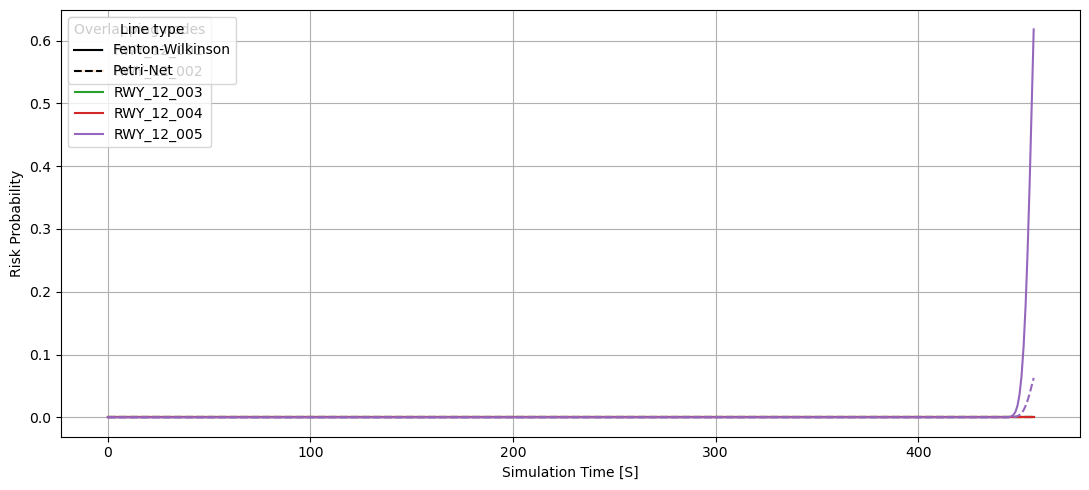

In [53]:
# deterministic_timeline_node_risk_cumulative.py
# ---------------------------------------------------------
# Deterministic timeline from fixed segment speeds (km/h).
# Time-resolved, per-second PN/FW *instantaneous* risk, then
# cumulative risk curves (monotone increasing) per node.
#
# Solid = FW cumulative, Dashed = PN cumulative (same color per node).

import math
from typing import List, Tuple, Dict, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import norm  # narrow time-PDF around deterministic ETA

SEC_PER_HOUR = 3600.0  # time axis in seconds

def normalize_node(n: str) -> str:
    return n.strip().upper()

def link_lookup_distance(link_dist_km: Dict[Tuple[str,str], float], a: str, b: str) -> Optional[float]:
    a_u, b_u = normalize_node(a), normalize_node(b)
    for (ka,kb), d in link_dist_km.items():
        if (normalize_node(ka)==a_u and normalize_node(kb)==b_u) or (normalize_node(ka)==b_u and normalize_node(kb)==a_u):
            return d
    return None

def overlap_nodes_ordered_by_path(path_ref: List[str], path_other: List[str]) -> List[str]:
    s_other = set([normalize_node(x) for x in path_other])
    return [normalize_node(x) for x in path_ref if normalize_node(x) in s_other]

def deterministic_arrival_seconds(
    path: List[str],
    link_dist_km: Dict[Tuple[str,str], float],
    seg_speeds_kmh: List[float]
) -> List[float]:
    assert len(seg_speeds_kmh) == len(path) - 1, "Speed list must match #segments."
    t = [0.0]
    for i in range(len(path)-1):
        d_km = link_lookup_distance(link_dist_km, path[i], path[i+1])
        if d_km is None:
            raise KeyError(f"Missing distance for link ({path[i]}, {path[i+1]})")
        v_kmh = float(seg_speeds_kmh[i])
        if v_kmh <= 0:
            raise ValueError(f"Non-positive speed for segment {i}: {v_kmh}")
        dt_sec = (d_km / v_kmh) * SEC_PER_HOUR
        t.append(t[-1] + dt_sec)
    return t  # len == len(path)

# ---- repeated-node helpers ----
def all_occurrences(path: List[str], node: str) -> List[int]:
    node_u = normalize_node(node)
    return [i for i, n in enumerate([normalize_node(x) for x in path]) if n == node_u]

def eta_seconds_to_node_occ(
    path: List[str],
    link_dist_km: Dict[Tuple[str,str], float],
    seg_speeds_kmh: List[float],
    idx: int
) -> float:
    assert 0 <= idx < len(path)
    t = 0.0
    for i in range(idx):
        d = link_lookup_distance(link_dist_km, path[i], path[i+1])
        v = seg_speeds_kmh[i]
        t += (d / v) * SEC_PER_HOUR
    return t

def best_occurrence_by_eta_match(
    path_A: List[str], link_dist_km: Dict[Tuple[str,str], float], speeds_A_kmh: List[float],
    target_eta_sec: float, node: str
) -> int:
    cand = all_occurrences(path_A, node)
    if not cand:
        raise ValueError(f"Node {node} not found on the path.")
    etas = [eta_seconds_to_node_occ(path_A, link_dist_km, speeds_A_kmh, i) for i in cand]
    k_best = min(range(len(cand)), key=lambda k: abs(etas[k] - target_eta_sec))
    return cand[k_best]

# ---- main risk (instantaneous + cumulative) ----
def risk_timeseries_from_deterministic(
    path_A: List[str], path_B: List[str],
    link_dist_km: Dict[Tuple[str,str], float],
    speedsA_kmh: List[float], speedsB_kmh: List[float],
    rc_km: float,
    epsilon_sec: float = 1.0,
    nodes_of_interest: Optional[List[str]] = None,
    dt_sec: int = 1,
    gaussian_sigma_sec: float = 2.0  # width of time-PDF around deterministic ETA
) -> Tuple[pd.DataFrame, np.ndarray]:
    """
    Returns tidy DataFrame with columns:
      ['time_sec','node','R_PN','R_FW','Cum_PN','Cum_FW']
    and the time grid (seconds).
    """
    pA = [normalize_node(x) for x in path_A]
    pB = [normalize_node(x) for x in path_B]
    nodes = overlap_nodes_ordered_by_path(pB, pA) if nodes_of_interest is None \
            else [normalize_node(x) for x in nodes_of_interest]

    # time grid
    T_end = int(math.ceil(max(deterministic_arrival_seconds(pA, link_dist_km, speedsA_kmh)[-1],
                              deterministic_arrival_seconds(pB, link_dist_km, speedsB_kmh)[-1])))
    t_grid = np.arange(0, T_end + 1, dt_sec, dtype=float)
    eps = float(epsilon_sec)
    std_sec = max(float(gaussian_sigma_sec), 1e-6)

    rows = []
    for node in nodes:
        # Choose B’s occurrence (use last occurrence by default: typical end conflict)
        occB_list = all_occurrences(pB, node)
        iB = occB_list[-1]
        etaB = eta_seconds_to_node_occ(pB, link_dist_km, speedsB_kmh, iB)

        # Choose A’s occurrence closest to B’s ETA
        iA = best_occurrence_by_eta_match(pA, link_dist_km, speedsA_kmh, etaB, node)
        etaA = eta_seconds_to_node_occ(pA, link_dist_km, speedsA_kmh, iA)

        # per-second densities around ETAs
        fA = norm.pdf(t_grid, loc=etaA, scale=std_sec)
        fB = norm.pdf(t_grid, loc=etaB, scale=std_sec)

        # instantaneous risks (per second)
        Rpn = 2.0 * eps * fA * fB
        # FW instantaneous factor: average of 1/v (hours/km) from incoming segments, -> seconds/km
        vA_in = speedsA_kmh[iA-1] if iA > 0 else speedsA_kmh[0]
        vB_in = speedsB_kmh[iB-1] if iB > 0 else speedsB_kmh[0]
        e_inv_sec_per_km = 0.5 * (1.0/max(vA_in,1e-9) + 1.0/max(vB_in,1e-9)) * SEC_PER_HOUR
        Rfw = 2.0 * rc_km * e_inv_sec_per_km * fA * fB

        # cumulative (monotone): simple Riemann sum with dt=1 sec
        Cum_PN = np.cumsum(Rpn) * dt_sec
        Cum_FW = np.cumsum(Rfw) * dt_sec

        rows.append(pd.DataFrame({
            "time_sec": t_grid,
            "node": node,
            "R_PN": Rpn,
            "R_FW": Rfw,
            "Cum_PN": Cum_PN,
            "Cum_FW": Cum_FW
        }))

    df = pd.concat(rows, ignore_index=True).sort_values(["time_sec", "node"]).reset_index(drop=True)
    return df, t_grid

# ------------------ Demo with your speeds ------------------
if __name__ == "__main__":
    # Aircraft A (e.g., KLM 4805)
    path_A = ['Rwy_12_001','Rwy_12_002','Rwy_12_003','Rwy_12_004','Rwy_12_005','Rwy_12_006','Rwy_12_005']
    speedsA_kmh = [34.74, 34.72301886792452, 34.435102040816325, 25.014857142857146, 25.362947368421054, 89.24]

    # Aircraft B (e.g., Clipper 1736)
    path_B = ['Txy_C0_001','Txy_C0_002','Rwy_12_001','Rwy_12_002','Rwy_12_003','Rwy_12_004','Rwy_12_005']
    speedsB_kmh = [3.275702479338843, 3.3094736842105266, 27.5025, 27.467462686567163, 27.21483870967742, 16.21333333333333]

    # Distances (km)
    link_dist_km = {
        ('Txy_C0_001','Txy_C0_002'): 0.1101,
        ('Txy_C0_002','Rwy_12_001'): 0.0524,
        ('Rwy_12_001','Rwy_12_002'): 0.7334,
        ('Rwy_12_002','Rwy_12_003'): 0.5112,
        ('Rwy_12_003','Rwy_12_004'): 0.4687,
        ('Rwy_12_004','Rwy_12_005'): 0.2432,
        ('Rwy_12_005','Rwy_12_006'): 1.3386,
        ('Rwy_12_006','Rwy_12_005'): 1.3386,
    }

    # Overlapping nodes (ordered by path_B)
    nodes_of_interest = ['Rwy_12_001','Rwy_12_002','Rwy_12_003','Rwy_12_004','Rwy_12_005']

    # Risk params
    rc_km = 0.075      # spatial capture radius
    eps_sec = 1.0      # PN coincidence window (sec)
    std_eta_sec = 5.0  # Gaussian width around deterministic ETAs (sec)

    df, t_grid = risk_timeseries_from_deterministic(
        path_A, path_B, link_dist_km,
        speedsA_kmh, speedsB_kmh,
        rc_km=rc_km,
        epsilon_sec=eps_sec,
        nodes_of_interest=nodes_of_interest,
        dt_sec=1,
        gaussian_sigma_sec=std_eta_sec
    )

    # Sanity: full time range
    print("time range (s):", int(df["time_sec"].min()), "→", int(df["time_sec"].max()))
    print(df.head(6)); print(df.tail(6))

    # -------- Plot cumulative risk (monotone) --------
    fig, ax = plt.subplots(figsize=(11,5))
    color_handles = []
    for node, sub in df.groupby("node", sort=False):
        # same color: solid = FW cumulative; dashed = PN cumulative
        ln_fw, = ax.plot(sub["time_sec"], sub["Cum_FW"], label=node)                       # solid FW
        ax.plot(sub["time_sec"], sub["Cum_PN"], linestyle="--", color=ln_fw.get_color())   # dashed PN
        color_handles.append(ln_fw)

    ax.set_xlabel("Simulation Time [S]")
    ax.set_ylabel("Risk Probability")

    # Two-part legend
    legend_nodes = ax.legend(handles=color_handles, title="Overlapping nodes", loc="upper left", frameon=True)
    legend_styles = ax.legend(handles=[
        Line2D([0],[0], color="black", linestyle="-", label="Fenton-Wilkinson"),
        Line2D([0],[0], color="black", linestyle="--", label="Petri-Net"),
    ], title="Line type", loc="upper left", frameon=True)
    ax.add_artist(legend_nodes)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


[INFO] Final simulation time: 457.000 s
[INFO] Threshold intersections at y=0.05:
  RWY_12_001: FW -> — | PN -> —
  RWY_12_002: FW -> — | PN -> —
  RWY_12_003: FW -> — | PN -> —
  RWY_12_004: FW -> — | PN -> —
  RWY_12_005: FW -> 450.467 | PN -> 455.996


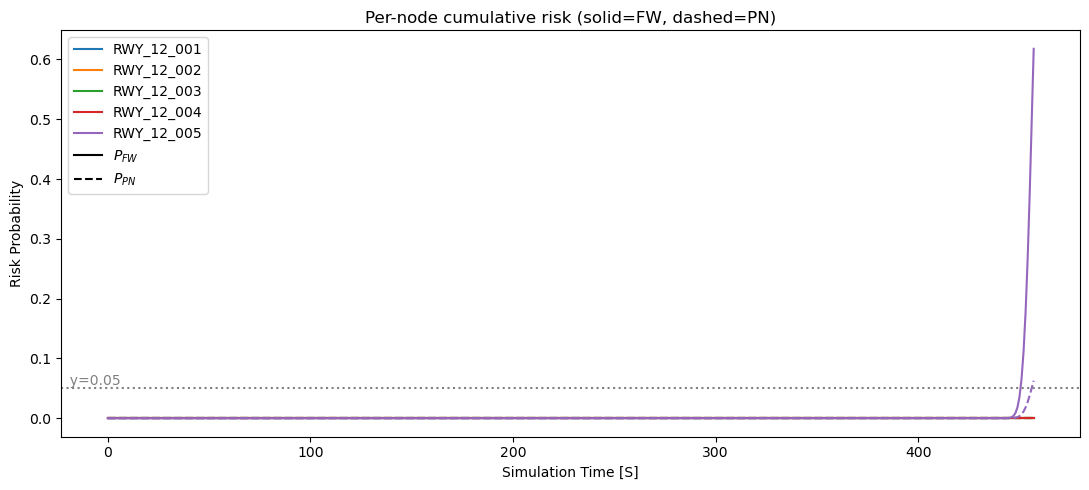

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def _find_intersections(x, y, y0):
    """
    Return list of x positions where the polyline (x, y) crosses the horizontal line y=y0.
    Uses linear interpolation segment-by-segment. Duplicate times (flat hits) are deduped.
    """
    xs = []
    for i in range(len(x) - 1):
        y1, y2 = y[i], y[i+1]
        if (y1 - y0) == 0 and (y2 - y0) == 0:
            # Entire segment lies on the threshold; skip to avoid infinite intersections.
            continue
        # Check for a crossing (including touching at an endpoint)
        if (y1 - y0) == 0:
            xs.append(x[i])
        if (y1 - y0) * (y2 - y0) < 0:
            # Proper crossing between i and i+1
            t = (y0 - y1) / (y2 - y1)
            xi = x[i] + t * (x[i+1] - x[i])
            xs.append(xi)
        if (y2 - y0) == 0:
            xs.append(x[i+1])
    # Deduplicate while preserving order (tolerance for near-equal floats)
    xs_sorted = []
    for v in xs:
        if not xs_sorted or abs(v - xs_sorted[-1]) > 1e-9:
            xs_sorted.append(v)
    return xs_sorted

def plot_risk_timeseries(
    df,
    nodes_order=None,
    use_cumulative=True,
    log_x=False,
    y_threshold=0.05,
    title="Per-node risk over time (solid = FW, dashed = PN)"
):
    """
    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns: 'time_sec', 'node' and either:
          - cumulative: 'Cum_FW', 'Cum_PN'   (use_cumulative=True)
          - instantaneous: 'R_FW', 'R_PN'    (use_cumulative=False)
    nodes_order : list[str] or None
        If provided, enforces plotting order for nodes; otherwise uses df order.
    use_cumulative : bool
        If True, plot cumulative curves; else plot instantaneous.
    log_x : bool
        If True, use a log-scaled x-axis.
    y_threshold : float
        Draw horizontal line at this y and compute intersections.
    title : str
        Figure title.

    Returns
    -------
    intersections : dict
        {'FW': {node: [t1, t2, ...]}, 'PN': {node: [t1, ...]}}
    final_time_sec : float
        Max time in df['time_sec'].
    fig, ax : matplotlib Figure and Axes
    """
    # Select columns based on cumulative/instantaneous
    fw_col = "Cum_FW" if use_cumulative else "R_FW"
    pn_col = "Cum_PN" if use_cumulative else "R_PN"

    if not {"time_sec", "node", fw_col, pn_col}.issubset(df.columns):
        raise ValueError(f"df must have columns: 'time_sec','node','{fw_col}','{pn_col}'.")

    # Sort by time then node for clean plotting
    df_plot = df.sort_values(["time_sec", "node"]).copy()

    # Determine plotting order for nodes
    if nodes_order is None:
        nodes = list(df_plot["node"].drop_duplicates().values)
    else:
        wanted = [str(n).strip().upper() for n in nodes_order]
        # normalize df nodes to uppercase for matching, but keep original labels when plotting
        # we'll filter in the given order where present
        all_nodes = {str(n).strip().upper(): n for n in df_plot["node"].unique()}
        nodes = [all_nodes[u] for u in wanted if u in all_nodes]

    fig, ax = plt.subplots(figsize=(11, 5))

    # Store one solid handle per node for legend color mapping
    node_handles = []
    intersections = {"FW": {}, "PN": {}}

    # Plot each node: solid = FW, dashed = PN (same color)
    for node in nodes:
        sub = df_plot[df_plot["node"] == node]
        x = sub["time_sec"].to_numpy()
        y_fw = sub[fw_col].to_numpy()
        y_pn = sub[pn_col].to_numpy()

        line_fw, = ax.plot(x, y_fw, label=node)  # solid by default
        ax.plot(x, y_pn, linestyle="--", color=line_fw.get_color())  # dashed same color
        node_handles.append(line_fw)

        # Intersections with y=y_threshold
        xs_fw = _find_intersections(x, y_fw, y_threshold)
        xs_pn = _find_intersections(x, y_pn, y_threshold)
        intersections["FW"][node] = xs_fw
        intersections["PN"][node] = xs_pn

    # Axes labels & options
    ax.set_xlabel("Simulation Time [S]")
    ax.set_ylabel("Risk Probability")
    ax.set_title(title)

    if log_x:
        # Log-scaling the x-axis; avoid zero by shifting the lower bound if needed
        xmin = max(1e-6, df_plot["time_sec"].min())
        ax.set_xscale("log")
        ax.set_xlim(left=xmin)

    # Horizontal threshold line
    ax.axhline(y_threshold, color="gray", linestyle=":", linewidth=1.5)
    ax.text(ax.get_xlim()[0], y_threshold, f"  y={y_threshold:g}", va="bottom", ha="left", color="gray")

    # Build a single, unified legend (nodes + line types)
    style_handles = [
        Line2D([0], [0], color="black", linestyle="-", label=r"$P_{FW}$"),
        Line2D([0], [0], color="black", linestyle="--", label=r"$P_{PN}$"),
    ]
    unified_handles = node_handles + style_handles
    ax.legend(handles=unified_handles, loc="upper left", frameon=True)

    # Final simulation time
    final_time_sec = float(df_plot["time_sec"].max())
    print(f"[INFO] Final simulation time: {final_time_sec:.3f} s")

    # Print intersections in a readable way
    def _fmt(xs):
        return ", ".join(f"{v:.3f}" for v in xs) if xs else "—"

    print(f"[INFO] Threshold intersections at y={y_threshold:g}:")
    for node in nodes:
        print(f"  {node}: FW -> {_fmt(intersections['FW'][node])} | PN -> {_fmt(intersections['PN'][node])}")

    plt.tight_layout()
    return intersections, final_time_sec, fig, ax

# If you plotted cumulative risk earlier:
# df has columns: time_sec, node, Cum_FW, Cum_PN
intersections, T_end, fig, ax = plot_risk_timeseries(
    df,
    nodes_order=['Rwy_12_001','Rwy_12_002','Rwy_12_003','Rwy_12_004','Rwy_12_005'],  # optional
    use_cumulative=True,     # or False if df has R_FW/R_PN
    log_x=False,             # set True if you want log-scaled x
    y_threshold=0.05,
    title="Per-node cumulative risk (solid=FW, dashed=PN)"
)

[INFO] Final simulation time: 457.000 s


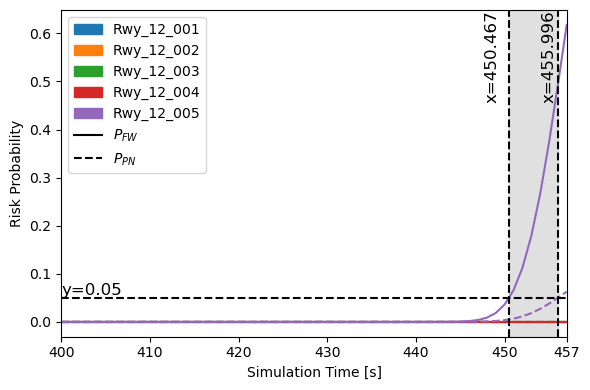

In [55]:
def plot_risk_timeseries(
    df,
    nodes_order=None,
    use_cumulative=True,
    y_threshold=0.05,
    title=None
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    fw_col = "Cum_FW" if use_cumulative else "R_FW"
    pn_col = "Cum_PN" if use_cumulative else "R_PN"

    if not {"time_sec", "node", fw_col, pn_col}.issubset(df.columns):
        raise ValueError(f"df must have columns: 'time_sec','node','{fw_col}','{pn_col}'.")

    # Sort and clip x range [400, 457]
    df_plot = df.sort_values(["time_sec", "node"]).copy()
    df_plot = df_plot[(df_plot["time_sec"] >= 400.0) & (df_plot["time_sec"] <= 457.0)].copy()

    # Node order
    if nodes_order is None:
        nodes = list(df_plot["node"].drop_duplicates().values)
    else:
        wanted = [str(n).strip().upper() for n in nodes_order]
        all_nodes = {str(n).strip().upper(): n for n in df_plot["node"].unique()}
        nodes = [all_nodes[u] for u in wanted if u in all_nodes]

    fig, ax = plt.subplots(figsize=(6, 4))
    color_handles = []
    last_crossings = []

    for node in nodes:
        sub = df_plot[df_plot["node"] == node]
        if sub.empty:
            continue
        x   = sub["time_sec"].to_numpy()
        yfw = sub[fw_col].to_numpy()
        ypn = sub[pn_col].to_numpy()

        ln_fw, = ax.plot(x, yfw, label=node)                       # FW solid
        ax.plot(x, ypn, linestyle="--", color=ln_fw.get_color())   # PN dashed
        color_handles.append((node, ln_fw.get_color()))

        xs_fw = _find_intersections(x, yfw, y_threshold)
        xs_pn = _find_intersections(x, ypn, y_threshold)

        last_fw = xs_fw[-1] if xs_fw else None
        last_pn = xs_pn[-1] if xs_pn else None

        ymax = ax.get_ylim()[1] if ax.lines else 1.0
        for xi, label_side in [(last_fw, "left"), (last_pn, "center")]:
            if xi is not None:
                ax.axvline(xi, color="black", linestyle="--", linewidth=1.5)
                ha_opt = "right" if label_side == "left" else "center"
                ax.text(xi-1, ymax, f"x={xi:.3f}", rotation=90,
                        va="top", ha=ha_opt, color="black", fontsize=12)
                last_crossings.append(xi)

    ax.set_xlim(400, 457)

    # Horizontal dashed threshold
    ax.axhline(y_threshold, color="black", linestyle="--", linewidth=1.5)
    ax.text(400, y_threshold, f"y={y_threshold:g}", va="bottom", ha="left", color="black", fontsize=12)

# Light grey shading between extremes
    if len(last_crossings) >= 2:

        x0, x1 = min(last_crossings), max(last_crossings)
        ax.axvspan(x0, x1, color="lightgrey", alpha=0.7)  # Much higher alpha for visibility


    ax.set_xlabel("Simulation Time [s]")
    ax.set_ylabel("Risk Probability")
    ax.set_title(title)

    # Legend: patches for nodes + line styles
    patches = []
    seen = set()
    for node, color in color_handles:
        nice_label = node.replace("RWY", "Rwy")
        if nice_label not in seen:
            patches.append(Patch(facecolor=color, edgecolor=color, label=nice_label))
            seen.add(nice_label)

    style_handles = [
        Line2D([0], [0], color="black", linestyle="-", label=r"$P_{FW}$"),
        Line2D([0], [0], color="black", linestyle="--", label=r"$P_{PN}$"),
    ]

    ax.legend(handles=patches + style_handles, loc="upper left", frameon=True)

    final_time_sec = float(df["time_sec"].max())
    print(f"[INFO] Final simulation time: {final_time_sec:.3f} s")
    ax.tick_params(axis='x', which='major', labelbottom=True)
    ax.set_xticks([400, 410, 420, 430, 440, 450, 457])
    plt.tight_layout()
    plt.savefig('tenerife-risk-figure.png', dpi=300)
    return fig, ax


# If you plotted cumulative risk earlier:
# df has columns: time_sec, node, Cum_FW, Cum_PN
fig, ax = plot_risk_timeseries(
    df,
    nodes_order=['Rwy_12_001','Rwy_12_002','Rwy_12_003','Rwy_12_004','Rwy_12_005'],  # optional
    use_cumulative=True,     # or False if df has R_FW/R_PN
    y_threshold=0.05,
)
